# Lab - 1

### Name: Anumalasetty Sohan Kumar  
### Roll No: CS23B1004

---
## Question 1

Implement the simple neural network algorithm from scratch in Python.
- Initialize the weights with [0 0 0] and a learning rate of 0.0001.
- For each iteration, calculate the output of the simple neural network for each input in the training set.
- Use MSE to computer the error for all samples
- Update the weights using the gradient descent procedure.
- Repeat the above steps until the simple neural network converges or a maximum number of iterations is reached.
- Test the trained simple neural network on a separate test set, explain how you came up with the test set.
- Use the step function as an  activation function in the output layer and sigmoid function for other layers.

Use the IRIS Dataset for the above, considering all four features: sepal length, sepal width, petal length, and petal width, but only two classes -  Setosa, and Versicolor.  Drop the feature vectors of the other class. 
Please find the dataset here - Iris Dataset

---

# Simple Neural Network from Scratch

## Overview
This project implements a simple neural network from scratch in Python for binary classification of IRIS flower species (Setosa vs Versicolor) using all four features: sepal length, sepal width, petal length, and petal width.

### Layer Details
1. **Input Layer**: 4 features + 1 bias term = 5 inputs
2. **Hidden Layer**: 3 neurons with sigmoid activation
3. **Output Layer**: 1 neuron with step function as activation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
df = pd.read_csv(r'iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [6]:
df = df[df['Species'] != 'Iris-virginica']
df.shape

(100, 6)

In [7]:
df.drop(columns=['Id'], inplace=True)

Iris-setosa - 0  
Iris-versicolor - 1

In [8]:
df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1
})

In [9]:
from sklearn.model_selection import train_test_split

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80, 4), (80,), (20, 4), (20,))

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

###  Loss Function
**Mean Squared Error (MSE)**:
```
MSE = (1/2) × Σ(y_true - y_pred)²

###  Activation Functions

#### Sigmoid Function (Hidden and Output layers during training)
```python
σ(x) = 1 / (1 + e^(-x))
```
- Smooth, differentiable function
- Output range: (0, 1)
- Used in hidden layer and output layer during training

#### Step Function (Output layer for prediction)
```python
f(x) = 1 if x ≥ 0, else 0
```
- Binary output: 0 or 1
- Used only for final predictions
- Threshold set at 0

In [13]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2) / 2

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [15]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [16]:
def step_function(z):
    return np.where(z >= 0, 1, 0)

In [17]:
np.random.seed(42)

input_size = 4
hidden_size = 3
output_size = 1

learning_rate = 0.0001
epochs = 1000

# weights initialized to zero (as required)
W1 = np.zeros((input_size, hidden_size))
b1 = np.zeros((1, hidden_size))

W2 = np.zeros((hidden_size, output_size))
b2 = np.zeros((1, output_size))

In [18]:
for epoch in range(epochs):

    # -------- Forward Pass --------
    z1 = np.dot(X_train_scaled, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred_continuous = sigmoid(z2)   # a2 (used for loss)
    y_pred = step_function(z2)         # final prediction

    # -------- Loss --------
    loss = mse(y_train, y_pred_continuous)

    # -------- Backpropagation --------
    # ouput layer
    # we take derivative wrt each loss fn so no summation
    d_loss_y_pred_continuous = -(y_train - y_pred_continuous)
    d_y_z2 = sigmoid_derivative(z2)

    delta2 = d_loss_y_pred_continuous * d_y_z2

    d_loss_W2 = np.dot(a1.T, delta2)
    d_loss_b2 = np.sum(delta2, axis=0, keepdims=True)

    # input layer
    d_loss_a1 = np.dot(delta2, W2.T)
    d_loss_z1 = d_loss_a1 * sigmoid_derivative(z1)

    d_loss_W1 = np.dot(X_train_scaled.T, d_loss_z1)
    d_loss_b1 = np.sum(d_loss_z1, axis=0, keepdims=True)

    delta1 = d_loss_z1

    # -------- Update Weights --------
    W2 -= learning_rate * d_loss_W2
    b2 -= learning_rate * d_loss_b2

    W1 -= learning_rate * d_loss_W1
    b1 -= learning_rate * d_loss_b1

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.1250
Epoch 100, Loss: 0.1250
Epoch 200, Loss: 0.1250
Epoch 300, Loss: 0.1250
Epoch 400, Loss: 0.1250
Epoch 500, Loss: 0.1250
Epoch 600, Loss: 0.1250
Epoch 700, Loss: 0.1250
Epoch 800, Loss: 0.1250
Epoch 900, Loss: 0.1250


### At output layer

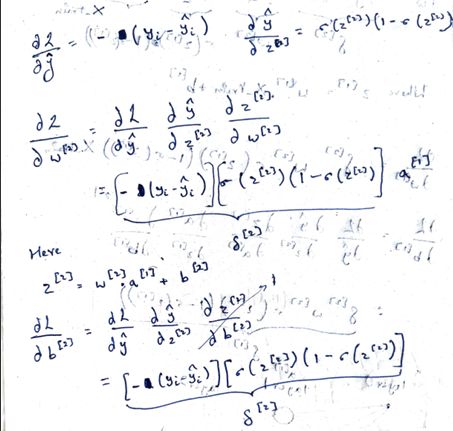

### At Hidden Layer

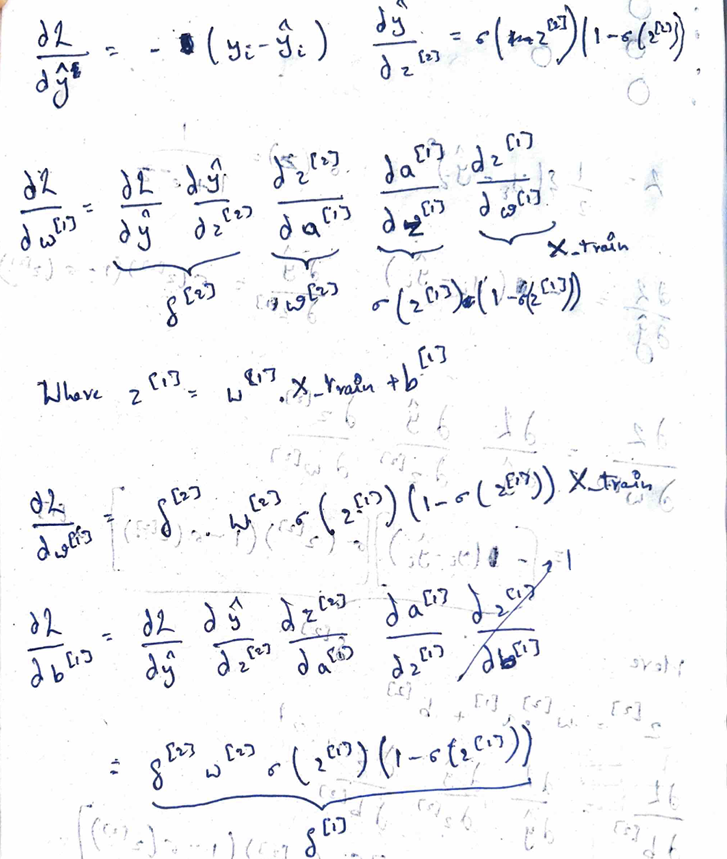

### Weight updation rule (Gradient Descent)

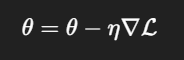

### Final weights

In [19]:
W1

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [20]:
b1

array([[0., 0., 0.]])

In [21]:
W2

array([[0.],
       [0.],
       [0.]])

In [22]:
b2

array([[0.]])

In [23]:
z1_test = np.dot(X_test_scaled, W1) + b1
a1_test = sigmoid(z1_test)

z2_test = np.dot(a1_test, W2) + b2
y_test_pred = step_function(z2_test)

print("predicted values for the test data")
print(y_test_pred)


accuracy = np.mean(y_test_pred == y_test)
print("Test Accuracy:", accuracy)

predicted values for the test data
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
Test Accuracy: 0.5


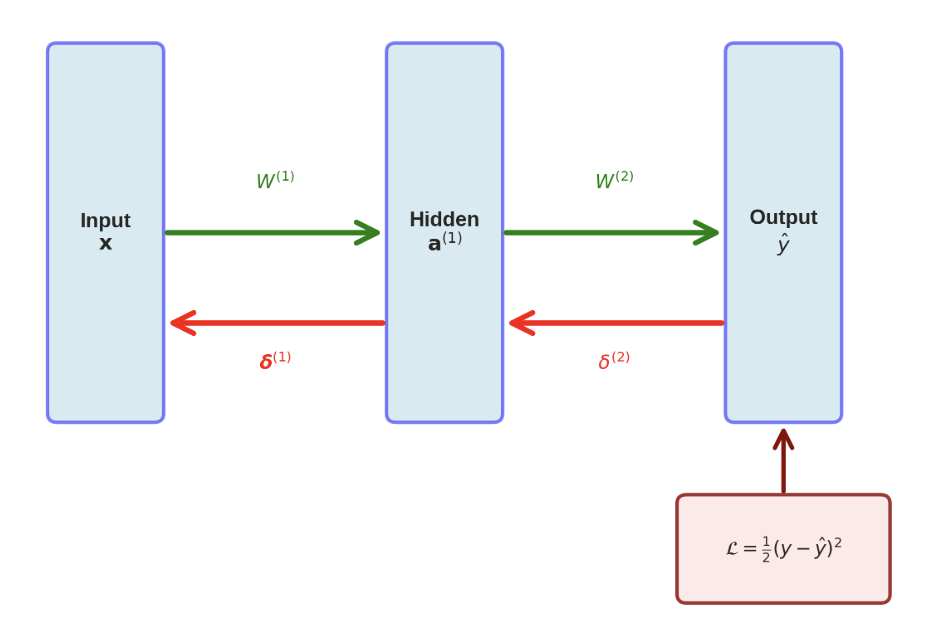

## Observation: Effect of Zero Initialization on Training

When all weights and biases of the neural network are initialized to zero, the network initially produces the same output for every input sample. Specifically, since the net input to each neuron is zero, the sigmoid activation function outputs a value of 0.5 for all samples.

For a binary classification problem with target labels {0, 1}, if the dataset is approximately balanced, a constant prediction of 0.5 results in a Mean Squared Error (MSE) of:

```
MSE = (1/2) × Σ(y_true - y_pred)²
```

This explains why the loss remains stuck at approximately **0.125** even after many training epochs.

The reason for this behavior is **symmetric weight initialization**. When all weights are initialized to the same value (zero), all neurons in a layer receive identical gradients during backpropagation and therefore update in the same way. As a result, the network fails to break symmetry and behaves like a constant predictor rather than learning meaningful feature representations.

This issue is further aggravated by the use of a **step function** at the output layer, which is non-differentiable and does not provide useful gradient information. Combined with a very small learning rate, the network is unable to move away from the initial flat region of the loss surface.

This experiment demonstrates an important limitation of zero initialization in neural networks and highlights the need for appropriate weight initialization strategies to enable effective learning.


## But the data is linearly separable so --> Simple Perceptron

In [26]:
W = np.zeros((4,1))
B = np.zeros((1,1))

In [30]:
epochs = 10
lr = 0.0001
mse_list = []

for epoch in range(epochs):
    
    # Forward pass
    Z = np.dot(X_train_scaled, W) + B
    output = step_function(Z)
    
    # Error and MSE
    error = y_train - output
    mse = np.mean(error**2)
    mse_list.append(mse)
    
    # Update weights (perceptron learning rule)
    W += lr * np.dot(X_train_scaled.T, error)
    B += lr * np.sum(error)
    
    if epoch % 2 == 0:
        print("Epoch:", epoch, "MSE:", mse)


Epoch: 0 MSE: 0.0
Epoch: 2 MSE: 0.0
Epoch: 4 MSE: 0.0
Epoch: 6 MSE: 0.0
Epoch: 8 MSE: 0.0


In [32]:
Z_test = np.dot(X_test_scaled, W) + B
predictions = step_function(Z_test)

accuracy = np.mean(predictions == y_test) * 100
print("Test Accuracy:", accuracy, "%")


Test Accuracy: 100.0 %
